In [1]:
from tifffile import imread
import os
from matplotlib import pyplot as plt
import json
from scipy.io import loadmat
import h5py
import numpy as np
import pandas as pd

In [2]:
pth_WSI_segmentations = r'\\10.162.80.16\Andre_expansion\data\monkey_fetus\Stardist\liver_cell_annotations\jsons'
npdi_im_path = r'\\10.162.80.16\Andre_expansion\data\monkey_fetus\Stardist\liver_cell_annotations'
hep_geojson_file = r'\\10.162.80.16\Andre_expansion\data\monkey_fetus\Stardist\liver_cell_annotations\geojsons_cell_type_annotations\monkey_fetus_40_0466_hepatoblast.geojson'
eryth_geojson_file = r'\\10.162.80.16\Andre_expansion\data\monkey_fetus\Stardist\liver_cell_annotations\geojsons_cell_type_annotations\monkey_fetus_40_0466_erythropoietic.geojson'

pth_dfs = r'\\10.162.80.16\Andre_expansion\data\monkey_fetus\Stardist\liver_cell_annotations\dfs'

In [3]:
json_pth_list = [os.path.join(pth_WSI_segmentations,file) for file in os.listdir(pth_WSI_segmentations) if file.endswith(".json")]
print(json_pth_list)

['\\\\10.162.80.16\\Andre_expansion\\data\\monkey_fetus\\Stardist\\liver_cell_annotations\\jsons\\monkey_fetus_40_0466.json', '\\\\10.162.80.16\\Andre_expansion\\data\\monkey_fetus\\Stardist\\liver_cell_annotations\\jsons\\monkey_fetus_40_0552.json', '\\\\10.162.80.16\\Andre_expansion\\data\\monkey_fetus\\Stardist\\liver_cell_annotations\\jsons\\monkey_fetus_40_0642.json']


In [4]:
im_list = os.listdir(npdi_im_path)
im_list = [im for im in im_list if im.endswith('.ndpi')]

In [5]:
# read one image
ind = 0

HE_20x_WSI = imread(os.path.join(npdi_im_path, im_list[ind]))

In [6]:
def show_tile(tile, **kwargs):
    """Plot a single image."""
    fig, ax = plt.subplots(1, 1, figsize=(16, 8))
    ax.imshow(tile, **kwargs)
    plt.tight_layout()
    ax.set_axis_off()
    plt.show()

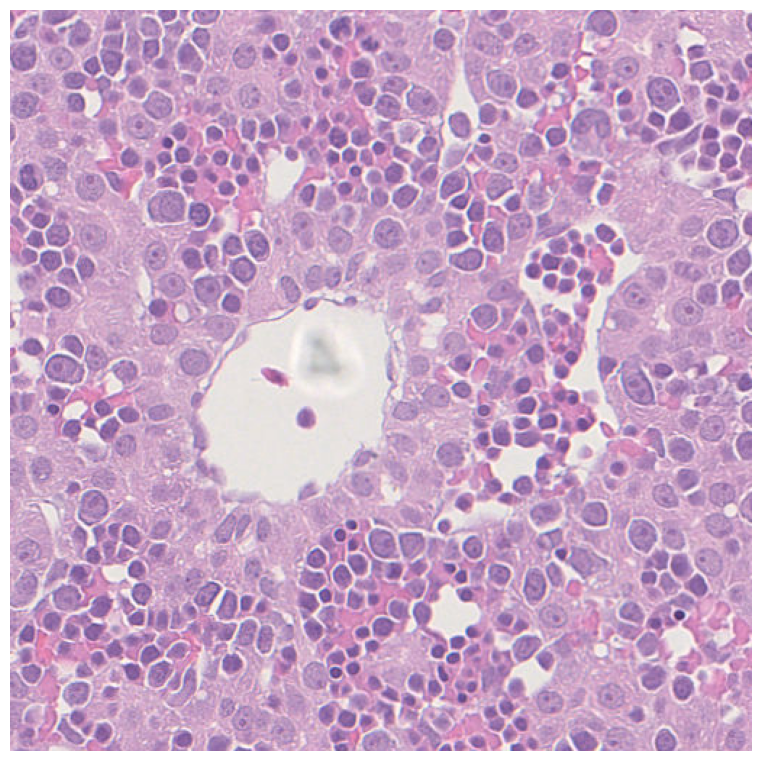

In [7]:
crop_x = 22611
crop_y = 14222
tile_size = 512

HE_20x_tile = HE_20x_WSI[crop_y:crop_y+tile_size, crop_x:crop_x+tile_size]

show_tile(HE_20x_tile)

In [8]:
hep_geo_data = json.load(open(hep_geojson_file))
print(hep_geojson_file)
print(hep_geo_data.keys())

\\10.162.80.16\Andre_expansion\data\monkey_fetus\Stardist\liver_cell_annotations\geojsons_cell_type_annotations\monkey_fetus_40_0466_hepatoblast.geojson
dict_keys(['type', 'features'])


In [9]:
eryth_geo_data = json.load(open(eryth_geojson_file))
print(eryth_geojson_file)
print(eryth_geo_data.keys())

\\10.162.80.16\Andre_expansion\data\monkey_fetus\Stardist\liver_cell_annotations\geojsons_cell_type_annotations\monkey_fetus_40_0466_erythropoietic.geojson
dict_keys(['type', 'features'])


In [10]:
hep_centroids_ann = []

for i in range(len(hep_geo_data['features'])):
    data = hep_geo_data['features'][i]
    coords = data['geometry']['coordinates'][0]
    
    x_cent = 0
    y_cent = 0
    for pair in coords:
        x_cent += pair[1] #+ crop_y
        y_cent += pair[0] #+ crop_x
    x_cent /= len(coords)
    y_cent /= len(coords)
    
    # print(x_cent, y_cent)
    hep_centroids_ann.append([x_cent, y_cent])
    
eryth_centroids_ann = []

for i in range(len(eryth_geo_data['features'])):
    data = eryth_geo_data['features'][i]
    coords = data['geometry']['coordinates'][0]
    
    x_cent = 0
    y_cent = 0
    for pair in coords:
        x_cent += pair[1] #+ crop_y
        y_cent += pair[0] #+ crop_x
    x_cent /= len(coords)
    y_cent /= len(coords)
    
    # print(x_cent, y_cent)
    eryth_centroids_ann.append([x_cent, y_cent])

In [11]:
print(json_pth_list[ind])
segmentation_data = json.load(open(json_pth_list[ind]))

# centroids = [nuc['centroid'][0] for nuc in segmentation_data]  # I wrote bad centroids in json file, but contours are right
contours = [nuc['contour'] for nuc in segmentation_data]
centroids = [[np.mean(xy[0][0]), np.mean(xy[0][1])] for xy in contours]
print(len(centroids))
print(len(contours))

\\10.162.80.16\Andre_expansion\data\monkey_fetus\Stardist\liver_cell_annotations\jsons\monkey_fetus_40_0466.json
569769
569769


In [12]:
hep_centroids_ann_np = np.array(hep_centroids_ann)
eryth_centroids_ann_np = np.array(eryth_centroids_ann)

centroids_total_np = np.array(centroids)

print(len(hep_centroids_ann_np))
print(len(eryth_centroids_ann_np))
print(len(centroids_total_np))

250
250
569769


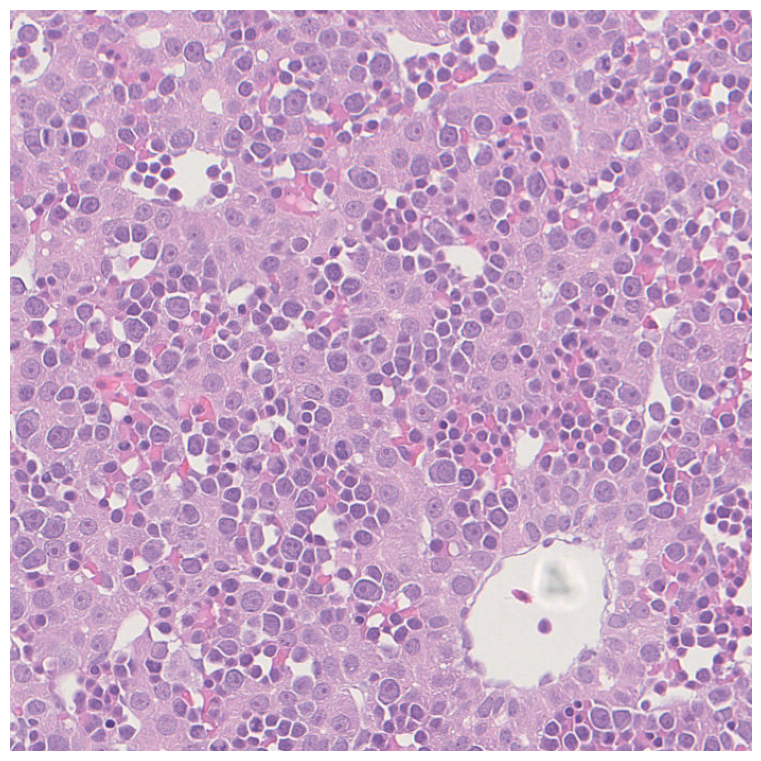

In [13]:
crop_x = 22311
crop_y = 13922
tile_size = 700

HE_20x_tile = HE_20x_WSI[crop_y:crop_y+tile_size, crop_x:crop_x+tile_size]

show_tile(HE_20x_tile)

In [14]:
# https://stackoverflow.com/questions/71027729/finding-optimal-nearest-neighbour-pairs

# match closest pairs of coordinates in two sets of x,y coordinates

from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix, csgraph

def colocalize_points(points_a: np.ndarray, points_b: np.ndarray, r: int):
    """ Find pairs that minimize global distance. Filters out anything outside radius `r` """

    neigh = NearestNeighbors(n_neighbors=1)
    neigh.fit(points_b)
    distances, b_indices = neigh.radius_neighbors(points_a, radius=r)

    # flatten and get indices for A. This will also drop points in A with no matches in range
    d_flat = np.hstack(distances) + 1
    b_flat = np.hstack(b_indices)
    a_flat = np.array([i for i, neighbors in enumerate(distances) for n in neighbors])

    # filter out A points that cannot be matched
    sm = csr_matrix((d_flat, (a_flat, b_flat)))
    a_matchable = csgraph.maximum_bipartite_matching(sm, perm_type='column')
    sm_filtered = sm[a_matchable != -1]

    # now run the distance minimizing matching
    row_match, col_match = csgraph.min_weight_full_bipartite_matching(sm_filtered)
    return row_match, col_match

In [15]:
hep_results = colocalize_points(hep_centroids_ann_np, centroids_total_np, r=20)
eryth_results = colocalize_points(eryth_centroids_ann_np, centroids_total_np, r=20)

In [16]:
def adjust_contours(contours_matched, x, y):

    contours_matched_adjusted = []
    for i in range(len(contours_matched)):
        contour = contours_matched[i][0]
        x_coords = contour[0]
        y_coords = contour[1]
        x_coords = [point-x for point in x_coords]
        y_coords = [point-y for point in y_coords]
        
        shape = list(zip(x_coords, y_coords))
        contours_matched_adjusted.append(shape)
    
    return contours_matched_adjusted

In [17]:
def get_contours_for_plot(results, centroids_ann_np, centroids_total_np):
    centroids_annotated = [centroids_ann_np[i] for i in results[0]]
    centroids_all = [centroids_total_np[i] for i in results[1]]
    centroids_matched = [pair.tolist() for pair in centroids_all]

    adj_centroids_matched = [[pair[0] - crop_y, pair[1] - crop_x] for pair in centroids_matched]
    
    adj_centroids = [[pair[0] - crop_y, pair[1] - crop_x] for pair in centroids]
    centroids_in_tile_seg = [pair for pair in adj_centroids if 0 < crop_y < tile_size and 0 < crop_x < tile_size and pair not in adj_centroids_matched]
    
    indices_matched = [adj_centroids.index(pair) for pair in adj_centroids if pair in adj_centroids_matched]
    
    indices_not_matched = [adj_centroids.index(pair) for pair in adj_centroids if 0 < pair[1] < tile_size and 0 < pair[0] < tile_size and pair not in adj_centroids_matched]  # and within crop range
    
    contours_matched = [contours[i] for i in indices_matched]
    contours_not_matched = [contours[i] for i in indices_not_matched] 
    
    contours_matched_adjusted = adjust_contours(contours_matched, crop_y, crop_x)
    contours_not_matched_adjusted = adjust_contours(contours_not_matched, crop_y, crop_x)
    
    return contours_matched_adjusted, indices_matched

In [18]:
hep_contours_matched_ajd, hep_indices_matched = get_contours_for_plot(hep_results, hep_centroids_ann_np, centroids_total_np)
eryth_contours_matched_ajd, eryth_indices_matched = get_contours_for_plot(eryth_results, eryth_centroids_ann_np, centroids_total_np)

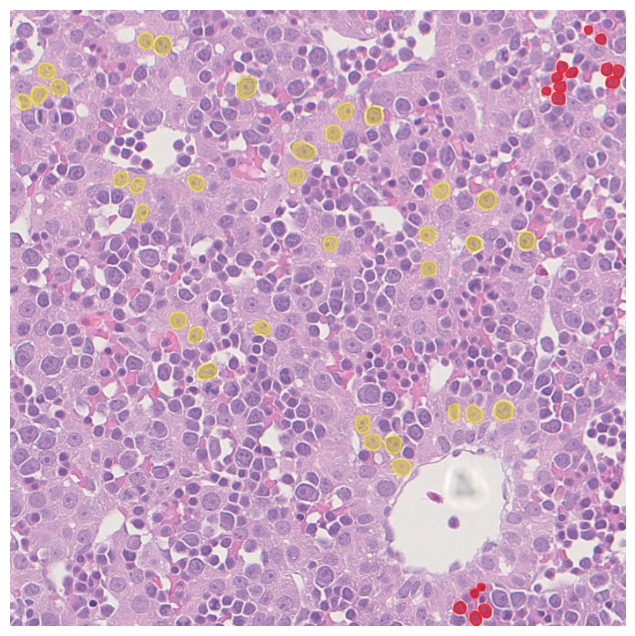

In [19]:
hep_reversed_contours = [[(y, x) for x, y in polygon] for polygon in hep_contours_matched_ajd]
eryth_reversed_contours = [[(y, x) for x, y in polygon] for polygon in eryth_contours_matched_ajd]

fig, ax = plt.subplots(figsize=(16, 8))

# Plot the image
ax.imshow(HE_20x_tile)
ax.set_axis_off()

for polygon in hep_reversed_contours:
    x_coords, y_coords = zip(*polygon)
    x_coords = list(x_coords) + [x_coords[0]]  # Close the polygon
    y_coords = list(y_coords) + [y_coords[0]]  # Close the polygon

    color = 'yellow'
    
    skip = False
    for x in x_coords:
        if x < 0 or x > (tile_size - 1):
            skip = True
            break
    for y in y_coords:
        if y < 0 or y > (tile_size - 1):
            skip = True
            break
    
    if not skip:
        ax.plot(x_coords, y_coords, alpha=0.3, color=color)
        ax.fill(x_coords, y_coords, alpha=0.3, color=color)  # Fill the polygon
    

for polygon in eryth_reversed_contours:
    x_coords, y_coords = zip(*polygon)
    x_coords = list(x_coords) + [x_coords[0]]  # Close the polygon
    y_coords = list(y_coords) + [y_coords[0]]  # Close the polygon

    color = 'red'
    
    skip = False
    for x in x_coords:
        if x < 0 or x > (tile_size - 1):
            skip = True
            break
    for y in y_coords:
        if y < 0 or y > (tile_size - 1):
            skip = True
            break
    
    if not skip:

        ax.plot(x_coords, y_coords, alpha=0.4, color=color)
        ax.fill(x_coords, y_coords, alpha=0.4, color=color)  # Fill the polygon

# Set labels and title for the plot
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
#ax.set_title('Qupath selected nuclei vs unselected')

plt.show()

In [20]:
df_pth_list = [os.path.join(pth_dfs,x) for x in os.listdir(pth_dfs)]

In [21]:
df_pth_list[0]

'\\\\10.162.80.16\\Andre_expansion\\data\\monkey_fetus\\Stardist\\liver_cell_annotations\\dfs\\monkey_fetus_40_0466.pkl'

In [22]:
import pickle

with open(df_pth_list[0], 'rb') as file:
    df = pickle.load(file)

In [23]:
print(df.shape)
print(len(centroids))
print(len(contours))

(569769, 20)
569769
569769


In [24]:
hep_df = df.iloc[hep_indices_matched,:]
eryth_df = df.iloc[eryth_indices_matched,:]

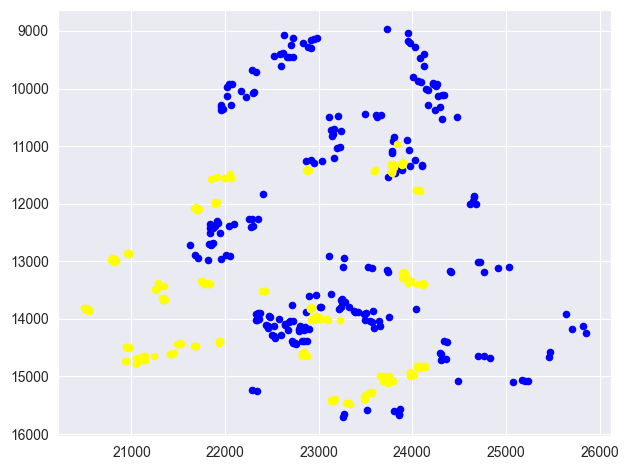

In [25]:
plt.scatter(hep_df['Centroid_x'], hep_df['Centroid_y'], c='blue', s=20)
plt.scatter(eryth_df['Centroid_x'], eryth_df['Centroid_y'], c='yellow', s=20)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [26]:
hep_df

,Centroid_x,Centroid_y,Area,Perimeter,Circularity,Aspect Ratio,compactness,eccentricity,extent,form_factor,maximum_radius,mean_radius,median_radius,minor_axis_length,major_axis_length,orientation_degrees,r_mean_intensity,g_mean_intensity,b_mean_intensity,slide_num
168689,22660.0,9458.0,93.861595,36.699089,0.875764,1.326375,14.349032,0.656950,0.771091,1.141860,7.350734,5.419937,5.216389,9.579835,12.706455,8469.908203,156.500000,120.639999,171.279999,466.0
170654,24094.0,9884.0,98.156807,35.912983,0.956373,1.096130,13.139610,0.409521,0.774768,1.045617,6.452393,5.594481,5.560056,10.750868,11.784345,5226.509277,163.710007,121.599998,173.050003,466.0
172209,23726.0,8972.0,281.455994,61.534843,0.934067,1.369493,13.453388,0.683236,0.775145,1.070587,11.463686,9.432269,9.238260,16.282986,22.299431,3730.507324,177.089996,142.539993,185.759995,466.0
172221,23956.0,9178.0,252.865005,57.172073,0.972144,1.084874,12.926447,0.387747,0.777955,1.028654,9.851697,8.991592,9.010938,17.309219,18.778326,7061.151855,188.320007,159.080002,194.050003,466.0
172521,23110.0,10502.0,210.799515,52.460644,0.962526,1.203122,13.055623,0.556017,0.777080,1.038934,9.870493,8.167806,8.245784,15.015752,18.065786,7975.950684,185.360001,153.300003,191.929993,466.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469229,25204.0,15072.0,261.459808,59.174080,0.938322,1.375959,13.392389,0.686885,0.774832,1.065732,10.959262,9.073375,9.212380,15.660153,21.547724,4021.643799,189.039993,155.279999,194.539993,466.0
469413,24322.0,14700.0,330.047394,66.019806,0.951563,1.232219,13.206028,0.584291,0.775823,1.050902,12.679114,10.201978,10.362234,18.580729,22.895527,5788.359375,167.080002,131.699997,180.020004,466.0
469414,24292.0,14592.0,343.066101,66.913383,0.962857,1.093558,13.051129,0.404707,0.775816,1.038576,11.474430,10.463621,10.626300,20.108919,21.990265,2401.014648,178.169998,140.690002,185.309998,466.0
469599,25172.0,15054.0,350.276642,67.692627,0.960591,1.058607,13.081922,0.328114,0.774569,1.041026,11.973433,10.561401,10.989968,20.668467,21.879774,7726.605469,184.380005,149.699997,191.600006,466.0


In [27]:
def fix_scale(dat):

    ds = 0.4416
    
    dat['Area'] = dat['Area']*.4416**2
    dat['Perimeter'] = dat['Perimeter']*ds
    dat['maximum_radius'] = dat['maximum_radius']*ds
    dat['mean_radius'] = dat['mean_radius']*ds
    dat['minor_axis_length'] = dat['minor_axis_length']*ds
    dat['major_axis_length'] = dat['major_axis_length']*ds
    
    return dat

In [28]:
hep_df2 = fix_scale(hep_df.copy())
eryth_df2 = fix_scale(eryth_df.copy())

In [29]:
cols_to_select = ['Area', 'Perimeter', 'Circularity', 'Aspect Ratio', 'compactness',
       'eccentricity', 'extent', 'form_factor', 'maximum_radius',
       'mean_radius', 'minor_axis_length', 'major_axis_length',
       'r_mean_intensity', 'g_mean_intensity',
       'b_mean_intensity']

good_names = ['Area (um)', 'Perimeter (um)', 'Circularity', 'Aspect Ratio', 'Compactness',
       'Eccentricity', 'Extent', 'Form Factor', 'Maximum Radius (um)',
       'Mean Radius (um)', 'Minor Axis Length (um)', 'Major Axis Length (um)',
       'Mean R Intensity', 'Mean G Intensity',
       'Mean B Intensity']

In [30]:
hep_df2['class'] = [1 for _ in range(len(hep_df2))]
eryth_df2['class'] = [2 for _ in range(len(eryth_df2))]

df_combined = pd.concat([hep_df2, eryth_df2], ignore_index=True)

In [31]:
df_combined.shape

(480, 21)

In [32]:
df_combined.head()

,Centroid_x,Centroid_y,Area,Perimeter,Circularity,Aspect Ratio,compactness,eccentricity,extent,form_factor,...,mean_radius,median_radius,minor_axis_length,major_axis_length,orientation_degrees,r_mean_intensity,g_mean_intensity,b_mean_intensity,slide_num,class
0,22660.0,9458.0,18.304003,16.206318,0.875764,1.326375,14.349032,0.656950,0.771091,1.141860,...,2.393444,5.216389,4.230455,5.611171,8469.908203,156.500000,120.639999,171.279999,466.0,1
1,24094.0,9884.0,19.141613,15.859173,0.956373,1.096130,13.139610,0.409521,0.774768,1.045617,...,2.470523,5.560056,4.747583,5.203967,5226.509277,163.710007,121.599998,173.050003,466.0,1
2,23726.0,8972.0,54.886890,27.173786,0.934067,1.369493,13.453388,0.683236,0.775145,1.070587,...,4.165290,9.238260,7.190567,9.847428,3730.507324,177.089996,142.539993,185.759995,466.0,1
3,23956.0,9178.0,49.311344,25.247187,0.972144,1.084874,12.926447,0.387747,0.777955,1.028654,...,3.970687,9.010938,7.643751,8.292509,7061.151855,188.320007,159.080002,194.050003,466.0,1
4,23110.0,10502.0,41.108131,23.166620,0.962526,1.203122,13.055623,0.556017,0.777080,1.038934,...,3.606903,8.245784,6.630956,7.977851,7975.950684,185.360001,153.300003,191.929993,466.0,1


In [38]:
df_combined.to_csv(r'C:\Users\Donald\Desktop\data_viz_class\idk.csv')

In [33]:
import seaborn as sns

cmap = [[235, 212, 200],
        [137, 151, 206]]

cmap = [[r/255, g/255, b/255] for r, g, b in cmap]

titles = ["Hepatoblast", "Erythropoietic"]

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Define your custom colormap
colors = [[209/255,214/255,125/255],'red']  # Colors for each class
cmap_name = 'custom_cma'
custom_cmap = mcolors.ListedColormap(colors, name=cmap_name)

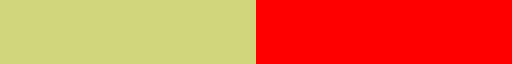

In [35]:
custom_cmap

ValueError: 'custom_cma' is not a valid value for cmap; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwar

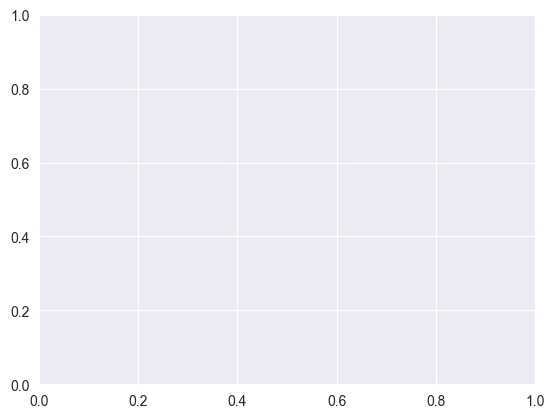

In [36]:
feature1= "Area"
feature2= "r_mean_intensity"
#plt.register_cmap(cmap=custom_cm)
plt.scatter(df_combined[feature1], df_combined[feature2],c=df_combined['class'],cmap='custom_cma')
plt.ylabel(feature2)
plt.xlabel(feature1)
plt.xlabel("Area", fontsize=20)
plt.ylabel("Mean Red Intensity", fontsize=20)
plt.savefig(fr'C:\Users\Donald\PycharmProjects\monkey_nuc_segment\Segmentation_Analysis\monkey\stardist_volcell\liver_cell_determination\figs\area_v_r_plot.png', dpi=300)
plt.show()

In [ ]:
i=0

fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(x="class", y=f"{cols_to_select[i]}", data=df_combined,palette=cmap,inner='box', inner_kws=dict(box_width=15, whis_width=2, color=".8"))
#sns.boxplot(x="class", y=f"{cols_to_select[i]}", data=df_combined, width=0.05)
ax.set_xticklabels(titles)
ax.set_xlabel('')
ax.set_ylabel(f'{good_names[i]}', fontsize=20)
plt.savefig(fr'C:\Users\Donald\PycharmProjects\monkey_nuc_segment\Segmentation_Analysis\monkey\stardist_volcell\liver_cell_determination\figs\{good_names[i]}_plot.png', dpi=300)
# plt.close()  # Close the current figure to free up memory
plt.show()

In [ ]:
for i in range(len(cols_to_select)):
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.violinplot(x="class", y=f"{cols_to_select[i]}", data=df_combined,palette=cmap)
    ax.set_xticklabels(titles)
    ax.set_xlabel('')
    ax.set_ylabel(f'{good_names[i]}', fontsize=20)
    plt.savefig(fr'C:\Users\Donald\PycharmProjects\monkey_nuc_segment\Segmentation_Analysis\monkey\stardist_volcell\liver_cell_determination\figs\{good_names[i]}_plot.png', dpi=300)
    # plt.close()  # Close the current figure to free up memory
    plt.show()

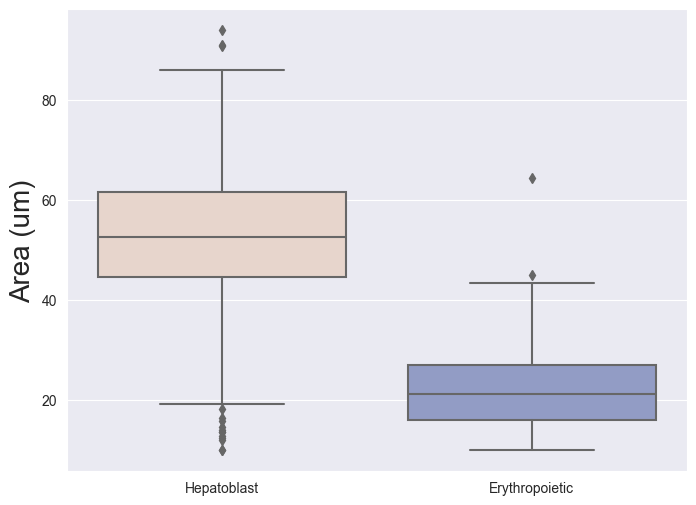

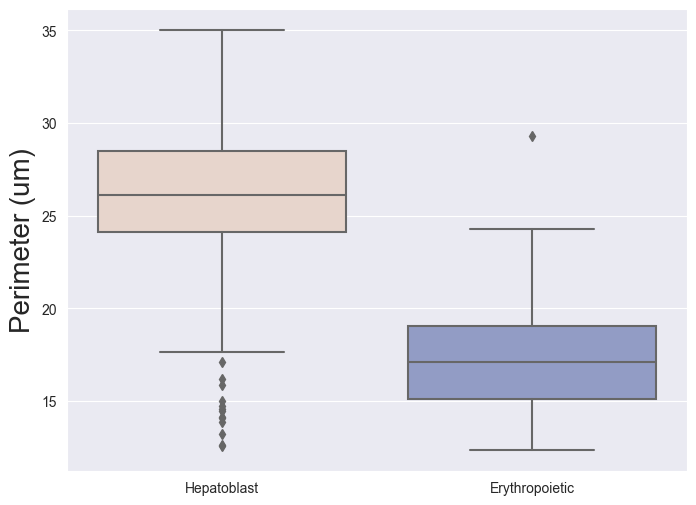

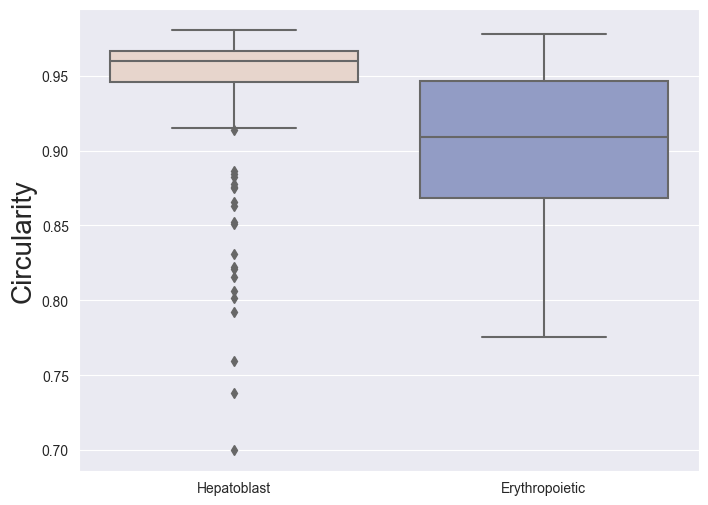

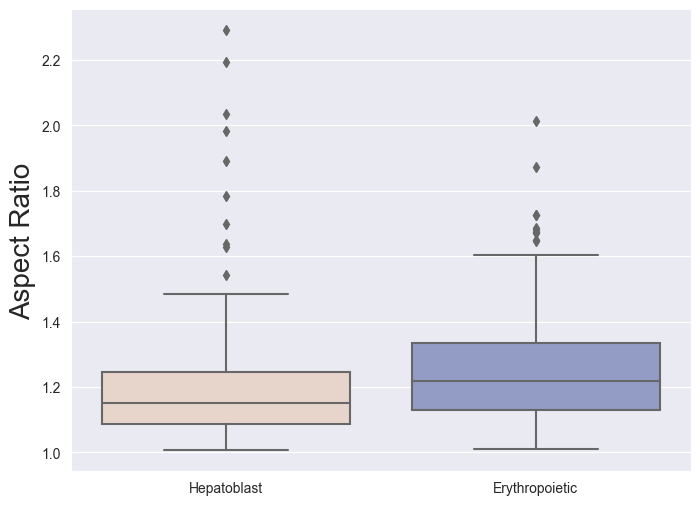

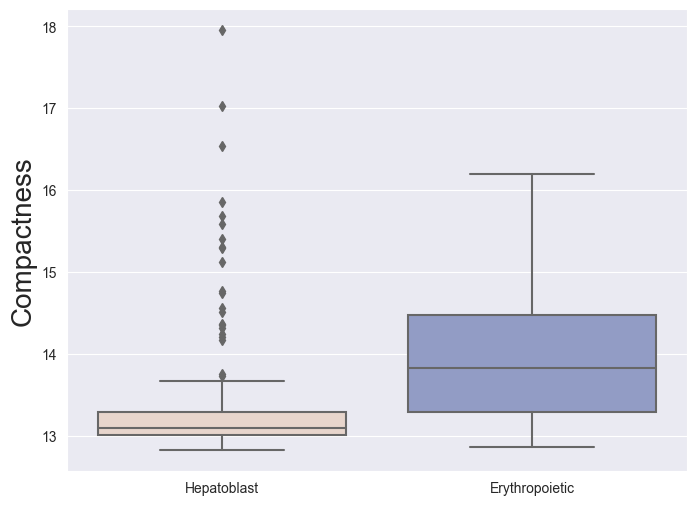

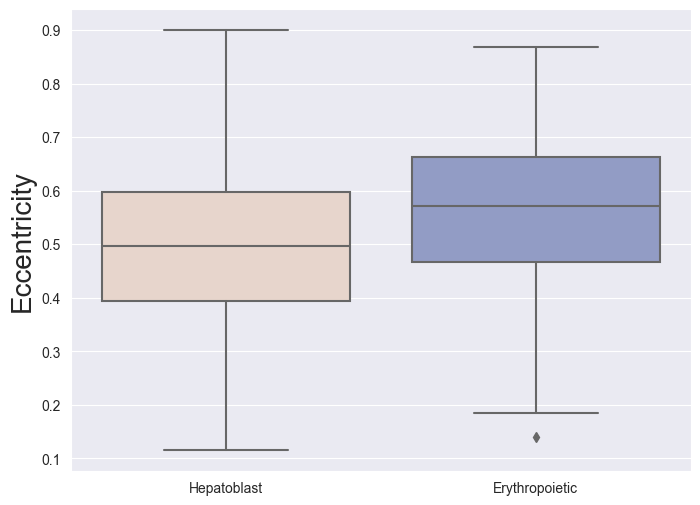

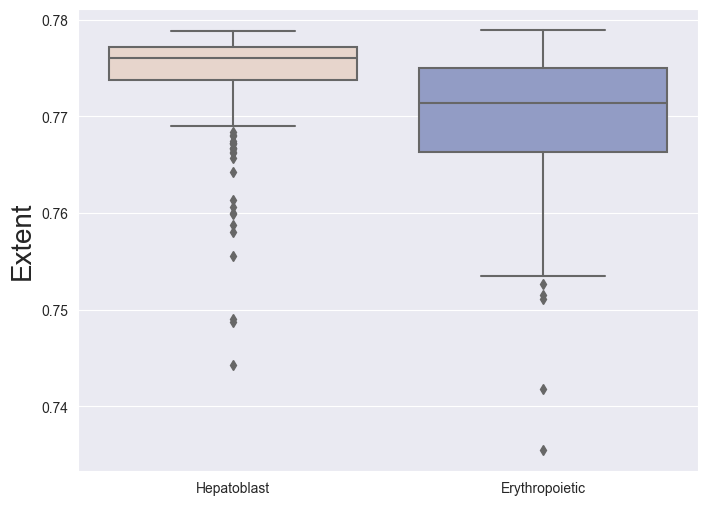

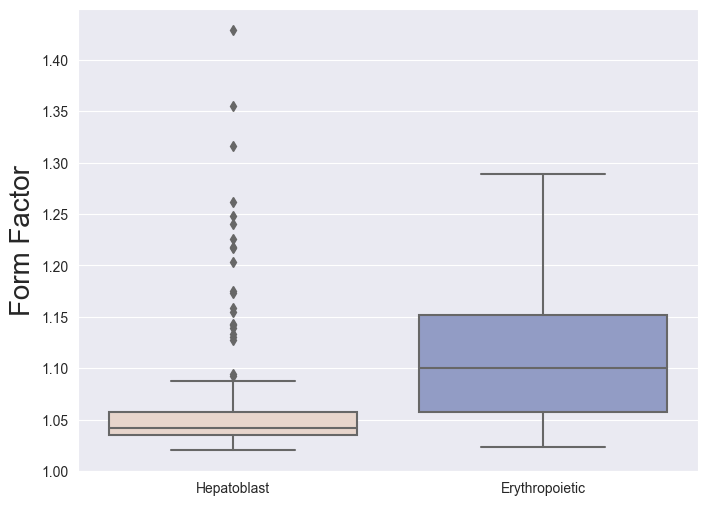

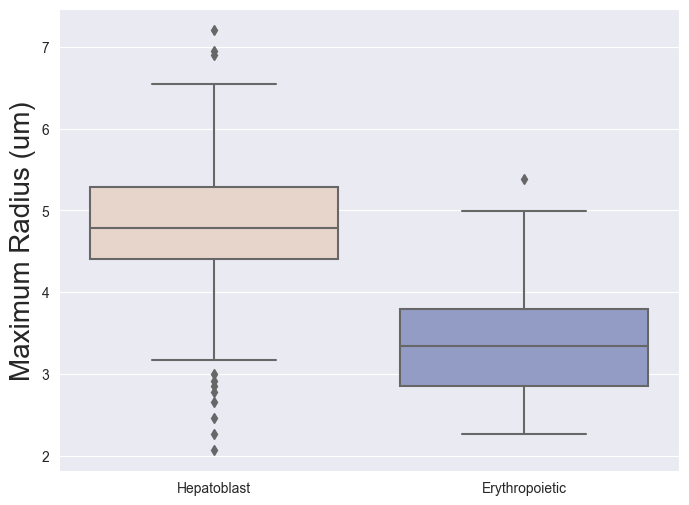

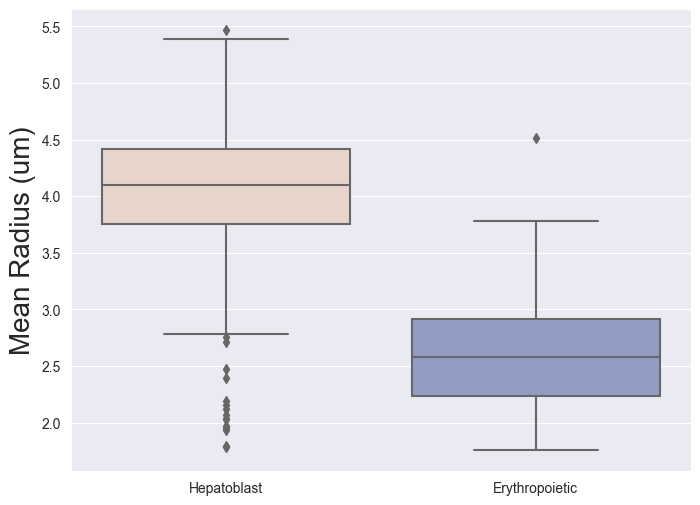

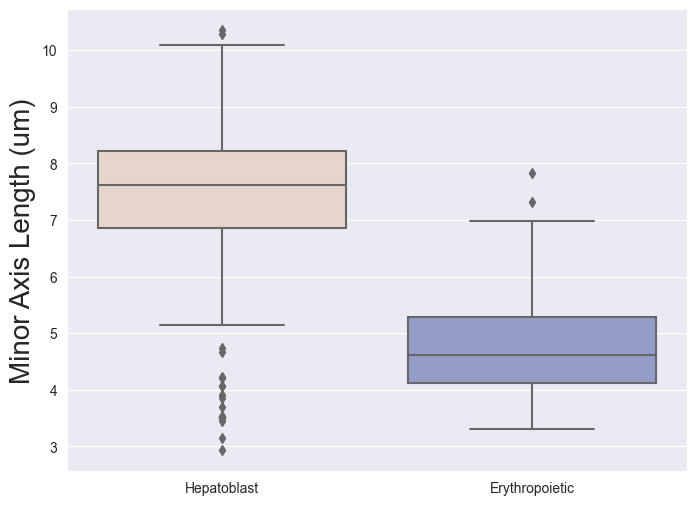

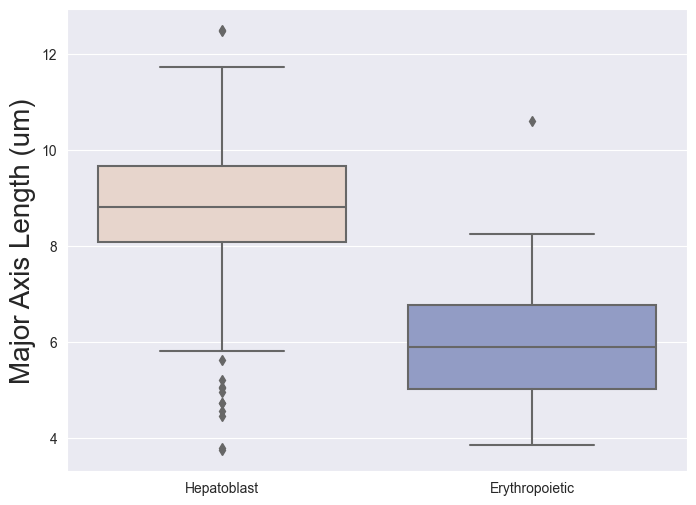

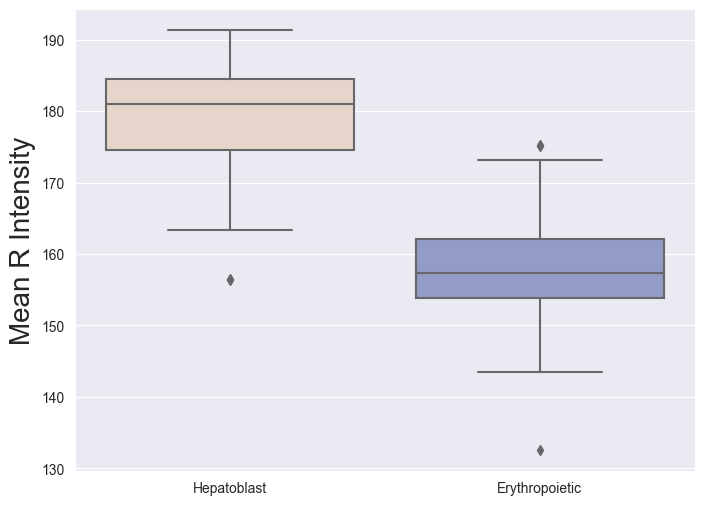

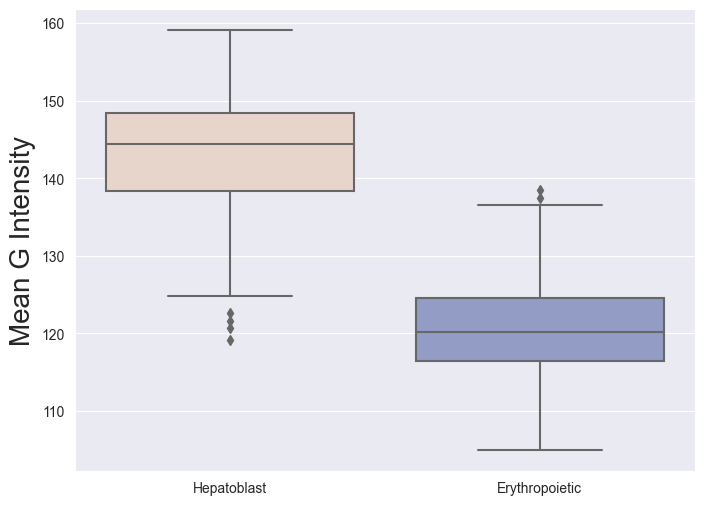

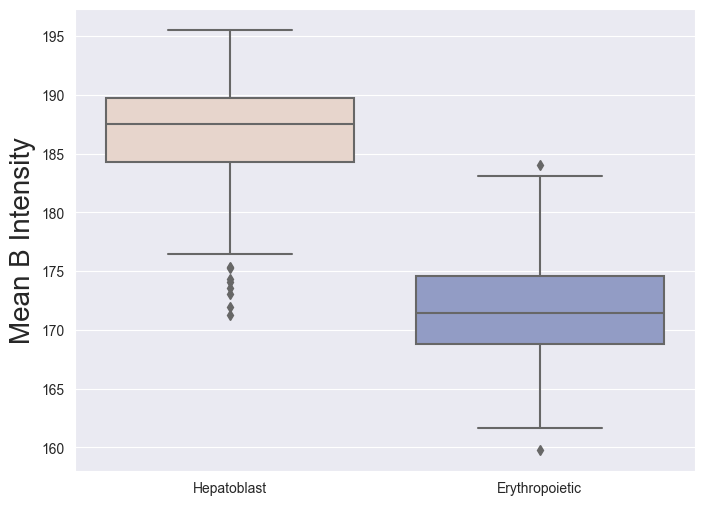

In [37]:
for i in range(len(cols_to_select)):
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(x="class", y=f"{cols_to_select[i]}", data=df_combined, palette=cmap)
    ax.set_xticklabels(titles)
    ax.set_xlabel('')
    ax.set_ylabel(f'{good_names[i]}', fontsize=20)
    # plt.savefig(fr'C:\Users\Donald\PycharmProjects\monkey_nuc_segment\Segmentation_Analysis\monkey\stardist_volcell\plots\kidney_nuc_feature_violins\{col}_plot.png', dpi=300)
    # plt.close()  # Close the current figure to free up memory
    plt.show()

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
norm = df_combined.copy()
norm = norm.iloc[:,2:-3].apply(lambda iterator: ((iterator - iterator.mean())/iterator.std()))
norm.head()

In [ ]:
pca2=PCA()
pca2.fit(norm)
pca2.explained_variance_ratio_

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(range(0,len(norm.columns)), pca2.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')

In [ ]:
pca = PCA(n_components=2)
pca.fit(norm)
pca.transform(norm)
scores_pca = pca.transform(norm)

In [ ]:
color_dict = dict(zip(np.unique(df_combined['class']), cmap))
colors = [color_dict[value] for value in df_combined['class']]

In [ ]:
colors

In [ ]:
""# Plot the transformed data (principal components)
plt.figure(figsize=(8, 6))
plt.scatter(scores_pca[:, 0], scores_pca[:, 1], color=colors, label='Principal Components', s=50)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
#plt.savefig(fr'C:\Users\Donald\PycharmProjects\monkey_nuc_segment\Segmentation_Analysis\monkey\stardist_volcell\plots\pdfs\pca_plot.png', dpi=300)  # Save the plot as a PDF file
plt.show()